# M5 Dataset Understanding

This notebook examines the structure, contents, data types and missing values of the three main M5 Forecasting Accuracy datasets.

The datasets will remain in their original wide formats during this initial examination.

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import duckdb

from pathlib import Path

In [3]:
project_root = Path.cwd()

if project_root.name == 'notebooks':
    project_root = project_root.parent

data_dir = project_root/'data'/'raw'/'m5'

sales_path = data_dir/'sales_train_evaluation.csv'
calendar_path = data_dir/'calendar.csv'
prices_path = data_dir/'sell_prices.csv'

print(f'Project root: {project_root}')
print(f'Data directory: {data_dir}')

Project root: c:\Users\ryana\OneDrive - MMU\Documents\MSc Project\retail-demand-forecasting
Data directory: c:\Users\ryana\OneDrive - MMU\Documents\MSc Project\retail-demand-forecasting\data\raw\m5


In [4]:
# directory pathing checks
for file_path in [sales_path, calendar_path, prices_path]:
    print(f'{file_path.name}: {file_path.exists()}')

sales_train_evaluation.csv: True
calendar.csv: True
sell_prices.csv: True


In [5]:
sales_df = pd.read_csv(sales_path)
calendar_df = pd.read_csv(calendar_path)
prices_df = pd.read_csv(prices_path)

### Examining the Sales Table

In [6]:
sales_df.shape

(30490, 1947)

In [7]:
sales_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [8]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), str(6)
memory usage: 454.7 MB


In [9]:
sales_df.isna().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 1947, dtype: int64

In [10]:
# Inspecting the column identifiers
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

sales_df[id_columns].head()

,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA


Findings:

`sales_train_evaluation.csv` contains one row for each item-store combination.  
The identifier columns describe the item, department, category, store and state.  
The columns beginning with `d_` contain the number of units sold on individual days.

### Examining the Calendar Table

In [11]:
calendar_df.shape

(1969, 14)

In [12]:
calendar_df.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [13]:
calendar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 263.1 KB


In [14]:
calendar_df.isna().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Findings:

`calendar.csv` connects the anonymous day identifiers, such as `d_1`, to actual
dates. It also contains weekday, month, year, event and SNAP programme information.

### Examining the Prices Table

In [15]:
prices_df.shape

(6841121, 4)

In [16]:
prices_df.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [17]:
prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB


In [18]:
prices_df.isna().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

Findings:

`sell_prices.csv` contains the weekly selling price of each item in each store.
The `wm_yr_wk` column connects it to the corresponding week in the calendar table.

## Prediction Target

The prediction target is future daily unit sales, or demand, for every item-store
combination. For the M5 evaluation task, the objective is to forecast the next
28 days after the final observed day in the training data.

### Understanding Retail Heirarchy

In [19]:
day_columns = [
    column for column in sales_df.columns
    if column.startswith('d_') # indicating the day of the sale
]

print(f'Sales Days: {len(day_columns):,}')
print(f'First three days: {day_columns[:3]}')
print(f'Last three days: {day_columns[-3:]}')

Sales Days: 1,941
First three days: ['d_1', 'd_2', 'd_3']
Last three days: ['d_1939', 'd_1940', 'd_1941']


In [20]:
hierarchy_summary = pd.DataFrame({
    'hierarchy_level': [
        'Items',
        'Stores',
        'Departments',
        'Categories',
        'States',
        'Item-store combinations'
    ],
    'count': [
        sales_df['item_id'].nunique(),
        sales_df['store_id'].nunique(),
        sales_df['dept_id'].nunique(),
        sales_df['cat_id'].nunique(),
        sales_df['state_id'].nunique(),
        sales_df[
            ['item_id', 'store_id']
        ].drop_duplicates().shape[0]
    ]
})

hierarchy_summary

,hierarchy_level,count
0,Items,3049
1,Stores,10
2,Departments,7
3,Categories,3
4,States,3
5,Item-store combinations,30490


The dataset contains 3,049 products distributed across 10 stores, producing 30,490 item–store forecasting series.

In [70]:
# Inspecting individual unique values
print('States:')
print(sorted(sales_df['state_id'].unique()))

print('\nStores:')
print(sorted(sales_df['store_id'].unique()))

print('\nCategories:')
print(sorted(sales_df['cat_id'].unique()))

print('\nDepartments:')
print(sorted(sales_df['dept_id'].unique()))

States:
['CA', 'TX', 'WI']

Stores:
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

Categories:
['FOODS', 'HOBBIES', 'HOUSEHOLD']

Departments:
['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


The M5 sales data has a hierarchical structure containing states, stores, categories, departments, and individual items.

In [ ]:
# Veryfy the example heirarchy
example_heirarchy = sales_df.loc[
    (sales_df['cat_id'] == 'FOODS') &
    (sales_df['dept_id'] == 'FOODS_1') &
    (sales_df['item_id'] == 'FOODS_1_001') &
    (sales_df['store_id'] == 'CA_1'),
    [
        'state_id', 'store_id', 'cat_id', 'dept_id', 'item_id','id'
    ]
]

example_heirarchy

,state_id,store_id,cat_id,dept_id,item_id,id
1612,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,FOODS_1_001_CA_1_evaluation


In [71]:
# Selecting CA_1 as the development store
development_store = 'CA_1'

store_df = sales_df[sales_df['store_id'] == development_store].copy()

print(f'Development store: {development_store}')
print(f'Rows: {store_df.shape[0]:,}')
print(f'Unique items: {store_df["item_id"].nunique():,}')
print(f'Departments: {store_df["dept_id"].nunique()}')
print(f'Categories: {store_df["cat_id"].nunique()}')
print(f"States: {store_df['state_id'].unique().tolist()}")

Development store: CA_1
Rows: 3,049
Unique items: 3,049
Departments: 7
Categories: 3
States: ['CA']


`CA_1` was selected as the initial development store and contains 3,049 item-level series.


In [72]:
# Identifying an item heirarchy
selected_item = 'FOODS_1_001'

item_metadata = store_df.loc[ # variable to hold the metadata for the selected item
    store_df['item_id'] == selected_item,
[
    'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'
]
]

item_metadata

,item_id,dept_id,cat_id,store_id,state_id
1612,FOODS_1_001,FOODS_1,FOODS,CA_1,CA


In [25]:
selected_dept = item_metadata['dept_id'].iloc[0]
selected_cat = item_metadata['cat_id'].iloc[0]

print(f'Selected item: {selected_item}')
print(f'Department: {selected_dept}')
print(f'Category: {selected_cat}')
print(f'Store: {development_store}')

Selected item: FOODS_1_001
Department: FOODS_1
Category: FOODS
Store: CA_1


In [74]:
# Calculating sales at the four heirarchy levels
product_sales = store_df.loc[store_df['item_id'] == selected_item, day_columns].sum(axis=0)

department_sales = store_df.loc[store_df['dept_id'] == selected_dept, day_columns].sum(axis=0)

category_sales = store_df.loc[store_df['cat_id'] == selected_cat, day_columns].sum(axis=0)

store_sales = store_df[day_columns].sum(axis=0)

hierarchical_sales = pd.DataFrame({
    selected_item: product_sales,
    selected_dept:department_sales,
    selected_cat: category_sales,
    development_store: store_sales
})

hierarchical_sales.index.name = 'd'
hierarchical_sales.head()

,FOODS_1_001,FOODS_1,FOODS,CA_1
d,,,,
d_1,3,297,3239,4337
d_2,0,284,3137,4155
d_3,0,214,2008,2816
d_4,1,175,2258,3051
d_5,4,182,2032,2630


In [ ]:
# Adding calendar and plotting the serie
plot_df = (
    hierarchical_sales
    .reset_index()
    .merge(
        calendar_df[['d', 'date']],
        on='d',
        how='left'
    )
)

plot_df['date'] = pd.to_datetime(plot_df['date'])

plot_df.head()

,d,FOODS_1_001,FOODS_1,FOODS,CA_1,date
0,d_1,3,297,3239,4337,2011-01-29
1,d_2,0,284,3137,4155,2011-01-30
2,d_3,0,214,2008,2816,2011-01-31
3,d_4,1,175,2258,3051,2011-02-01
4,d_5,4,182,2032,2630,2011-02-02


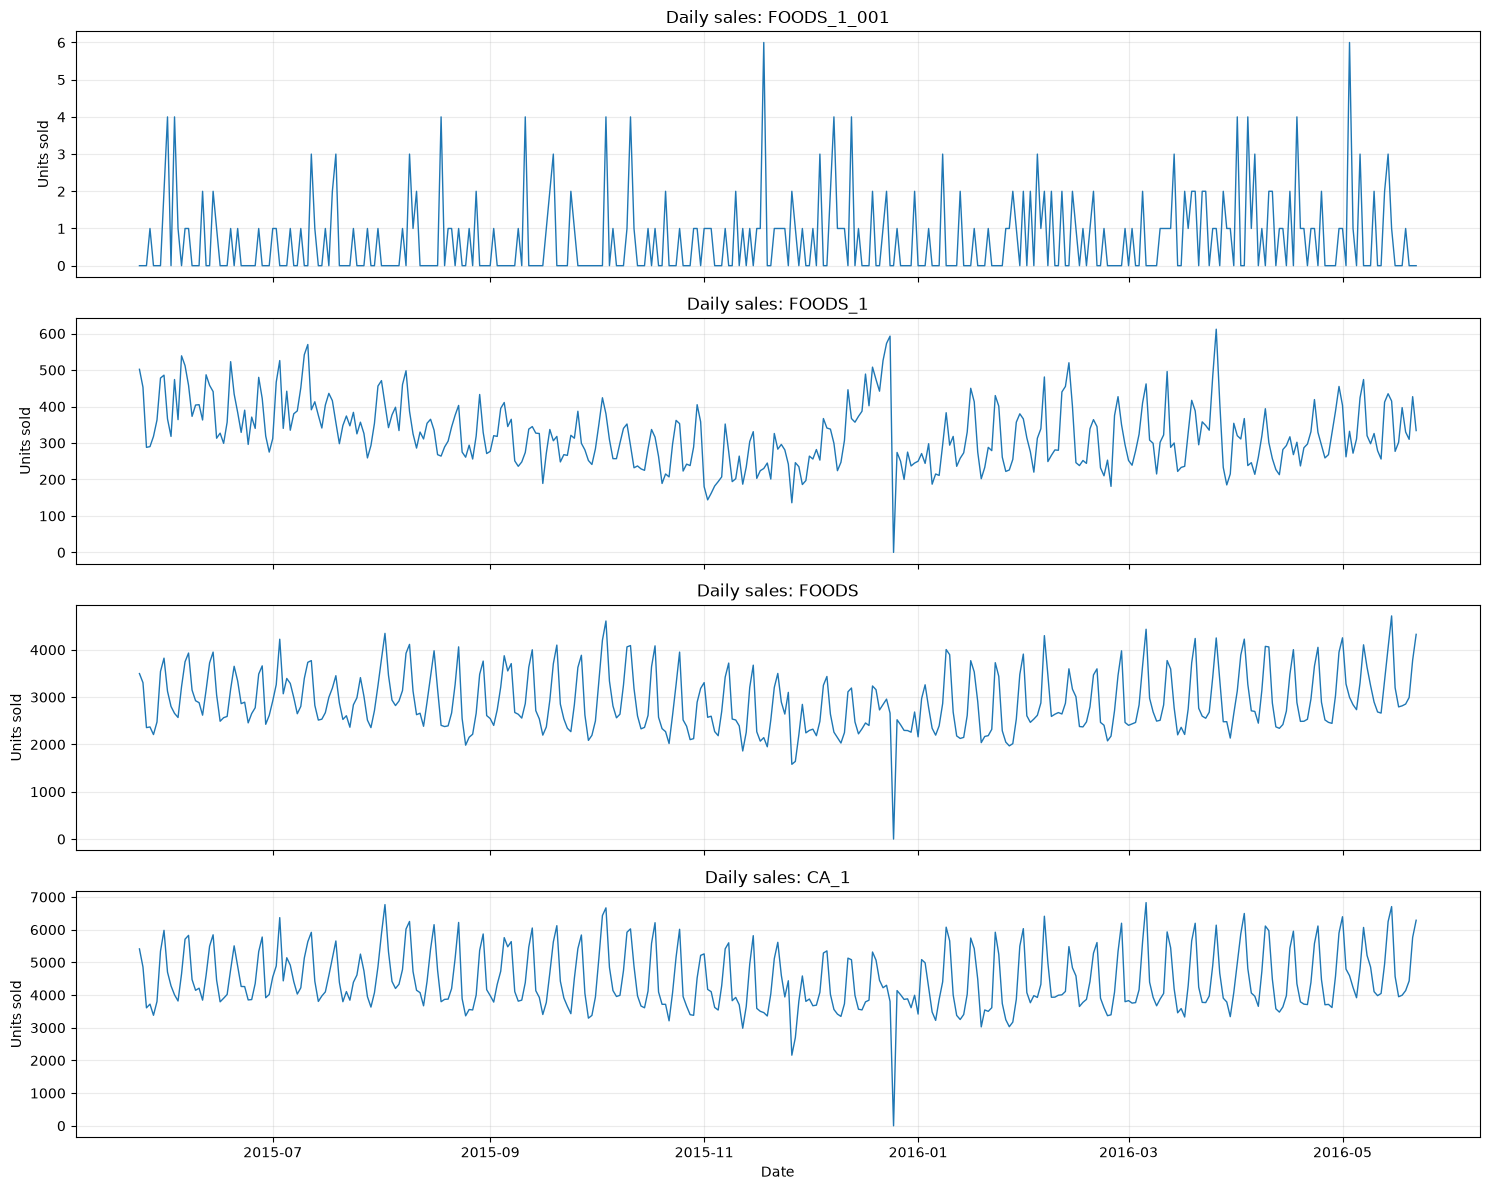

In [ ]:
# The lattest year
plot_days = 365
recent_sales = plot_df.tail(plot_days)

series_names = [
    selected_item,
    selected_dept,
    selected_cat,
    development_store
]

# plotting
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(15, 12),
    sharex=True
)

for axis, series_name in zip(axes, series_names):
    axis.plot(
        recent_sales['date'],
        recent_sales[series_name],
        linewidth=1
    )
    axis.set_title(f'Daily sales: {series_name}')
    axis.set_ylabel('Units sold')
    axis.grid(alpha=0.25)

axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [76]:
# Zero sales summary
def calculate_zero_summary(name, values):
    values_array = np.asarray(values)
    
    number_of_observations = values_array.size
    number_of_zeros = np.count_nonzero(values_array == 0)
    zero_percentage = (
        number_of_zeros / number_of_observations
    ) * 100
    
    return {
        'series_or_level': name,
        'observations': number_of_observations,
        'zero_sales': number_of_zeros,
        'zero_sales_percentage': zero_percentage
    }


store_item_sales = store_df[day_columns]

zero_sales_summary = pd.DataFrame([
    calculate_zero_summary(f'Product: {selected_item}', product_sales),
    calculate_zero_summary(f'All item-level observations in {development_store}', store_item_sales),
    calculate_zero_summary(f'Department: {selected_dept}', department_sales),
    calculate_zero_summary(f'Category: {selected_cat}', category_sales),
    calculate_zero_summary(f'Store: {development_store}', store_sales)
])

zero_sales_summary['zero_sales_percentage'] = (
    zero_sales_summary['zero_sales_percentage'].round(2)
)

zero_sales_summary

,series_or_level,observations,zero_sales,zero_sales_percentage
0,Product: FOODS_1_001,1941,1095,56.41
1,All item-level observations in CA_1,5918109,3773330,63.76
2,Department: FOODS_1,1941,5,0.26
3,Category: FOODS,1941,5,0.26
4,Store: CA_1,1941,5,0.26


In [30]:
len(store_df) * len(day_columns)

5918109

In [ ]:
# Examination between individual products
zero_rate_by_item = (
    store_item_sales
    .eq(0)
    .mean(axis=1)
    .mul(100)
)

item_zero_profile = (
    store_df[
        ['item_id', 'dept_id', 'cat_id']
    ]
    .assign(zero_sales_percentage=zero_rate_by_item)
    .sort_values(
        'zero_sales_percentage',
        ascending=False
    )
)

zero_rate_by_item.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
).round(2)

count    3049.00
mean       63.76
std        22.56
min         0.31
25%        47.81
50%        68.11
75%        82.33
90%        90.27
max        98.87
dtype: float64

In [32]:
# Item with highest zero sales
item_zero_profile.head(10)

,item_id,dept_id,cat_id,zero_sales_percentage
935,HOUSEHOLD_1_378,HOUSEHOLD_1,HOUSEHOLD,98.866564
25,HOBBIES_1_026,HOBBIES_1,HOBBIES,98.763524
2574,FOODS_3_350,FOODS_3,FOODS,97.681607
858,HOUSEHOLD_1_300,HOUSEHOLD_1,HOUSEHOLD,97.475528
430,HOBBIES_2_015,HOBBIES_2,HOBBIES,97.424008
1325,HOUSEHOLD_2_230,HOUSEHOLD_2,HOUSEHOLD,97.424008
1340,HOUSEHOLD_2_245,HOUSEHOLD_2,HOUSEHOLD,97.372488
2520,FOODS_3_296,FOODS_3,FOODS,97.372488
534,HOBBIES_2_119,HOBBIES_2,HOBBIES,97.063369
1689,FOODS_1_079,FOODS_1,FOODS,96.960330


In [33]:
# Item with lowest zero sales
item_zero_profile.tail(10)

,item_id,dept_id,cat_id,zero_sales_percentage
2613,FOODS_3_389,FOODS_3,FOODS,0.669758
2452,FOODS_3_228,FOODS_3,FOODS,0.618238
2892,FOODS_3_668,FOODS_3,FOODS,0.463679
2601,FOODS_3_377,FOODS_3,FOODS,0.463679
2918,FOODS_3_694,FOODS_3,FOODS,0.412159
2810,FOODS_3_586,FOODS_3,FOODS,0.360639
2937,FOODS_3_714,FOODS_3,FOODS,0.360639
2304,FOODS_3_080,FOODS_3,FOODS,0.309119
2476,FOODS_3_252,FOODS_3,FOODS,0.309119
2779,FOODS_3_555,FOODS_3,FOODS,0.309119


In [34]:
# Dataset-wide zero count
global_zero_count = 0
block_size = 100

for start in range(0, len(day_columns), block_size):
    block_columns = day_columns[start:start + block_size]
    
    global_zero_count += int(
        sales_df[block_columns]
        .eq(0)
        .to_numpy()
        .sum()
    )

global_observation_count = (
    len(sales_df) * len(day_columns)
)

global_zero_percentage = (
    global_zero_count / global_observation_count
) * 100

print(f'Total item-day observations: {global_observation_count:,}')
print(f'Zero-sales observations: {global_zero_count:,}')
print(f'Zero-sales percentage: {global_zero_percentage:.2f}%')

Total item-day observations: 59,181,090
Zero-sales observations: 40,241,819
Zero-sales percentage: 68.00%


## Understand time, events and prices

In [35]:
# Inspecting the calendar structure

calendar_columns = [
    'd',
    'date',
    'wm_yr_wk',
    'weekday',
    'wday',
    'month',
    'year',
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

calendar_df[calendar_columns].head()

,d,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2
0,d_1,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN
1,d_2,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN
2,d_3,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN
3,d_4,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN
4,d_5,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN


In [36]:
calendar_df.shape

(1969, 14)

In [37]:
calendar_df[calendar_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   d             1969 non-null   str  
 1   date          1969 non-null   str  
 2   wm_yr_wk      1969 non-null   int64
 3   weekday       1969 non-null   str  
 4   wday          1969 non-null   int64
 5   month         1969 non-null   int64
 6   year          1969 non-null   int64
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
dtypes: int64(4), str(7)
memory usage: 216.9 KB


In [38]:
# Madding 'd_1' to '_1941' to an actual date

calendar_df['date'] = pd.to_datetime(calendar_df['date'])

In [39]:
# Mapping

day_date_mapping = calendar_df.loc[
    calendar_df['d'].isin(day_columns),
    [
        'd',
        'date',
        'weekday',
        'wday',
        'month',
        'year',
        'wm_yr_wk'
    ]
].copy()

day_date_mapping.head()

,d,date,weekday,wday,month,year,wm_yr_wk
0,d_1,2011-01-29,Saturday,1,1,2011,11101
1,d_2,2011-01-30,Sunday,2,1,2011,11101
2,d_3,2011-01-31,Monday,3,1,2011,11101
3,d_4,2011-02-01,Tuesday,4,2,2011,11101
4,d_5,2011-02-02,Wednesday,5,2,2011,11101


In [40]:
# Inspecting head and tail in the mapping

pd.concat([
    day_date_mapping.head(),
    day_date_mapping.tail()
])

,d,date,weekday,wday,month,year,wm_yr_wk
0,d_1,2011-01-29,Saturday,1,1,2011,11101
1,d_2,2011-01-30,Sunday,2,1,2011,11101
2,d_3,2011-01-31,Monday,3,1,2011,11101
3,d_4,2011-02-01,Tuesday,4,2,2011,11101
4,d_5,2011-02-02,Wednesday,5,2,2011,11101
1936,d_1937,2016-05-18,Wednesday,5,5,2016,11616
1937,d_1938,2016-05-19,Thursday,6,5,2016,11616
1938,d_1939,2016-05-20,Friday,7,5,2016,11616
1939,d_1940,2016-05-21,Saturday,1,5,2016,11617
1940,d_1941,2016-05-22,Sunday,2,5,2016,11617


In [41]:
# Inpecting the date range
print(f'First Sales Date: {day_date_mapping['date'].min()}')
print(f'Last Sales Date: {day_date_mapping['date'].max()}')
print(f'Number of Mapped Days: {len(day_date_mapping):,}')

First Sales Date: 2011-01-29 00:00:00
Last Sales Date: 2016-05-22 00:00:00
Number of Mapped Days: 1,941


First sale 29 January 2011 and last sale is on 22 May 2016. 1,941 days in between.

In [42]:
# inspecting time variables
wday_mapping = (
    calendar_df[['wday', 'weekday']]
    .drop_duplicates()
    .sort_values('wday')
)

wday_mapping

,wday,weekday
0,1,Saturday
1,2,Sunday
2,3,Monday
3,4,Tuesday
4,5,Wednesday
5,6,Thursday
6,7,Friday


In [43]:
# inspecting each day's observations
calendar_df['weekday'].value_counts()

weekday
Saturday     282
Sunday       282
Monday       281
Tuesday      281
Wednesday    281
Thursday     281
Friday       281
Name: count, dtype: int64

In [44]:
# Inspecting month and year
print('Months:')
print(sorted(calendar_df['month'].unique()))

print('\nYears:')
print(sorted(calendar_df['year'].unique()))

Months:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]


In [45]:
calendar_df['year'].value_counts().sort_index()

year
2011    337
2012    366
2013    365
2014    365
2015    365
2016    171
Name: count, dtype: int64

Irregularities present in the year 2011 and 2016.

In [46]:
# Examining event names and types
event_columns = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

calendar_df[event_columns].head(10)

,event_name_1,event_type_1,event_name_2,event_type_2
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,SuperBowl,Sporting,NaN,NaN
9,NaN,NaN,NaN,NaN


In [47]:
# Count the missing values
calendar_df[event_columns].isna().sum()

event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

Missing values indicate no sales on that particular day

In [48]:
# Inspecting event types
calendar_df['event_type_1'].value_counts(
    dropna=False
)

event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

In [ ]:
# Inspecting event names
calendar_df['event_name_1'].value_counts(dropna=False).head(20)

event_name_1
NaN                1807
SuperBowl             6
ValentinesDay         6
PresidentsDay         6
LentStart             6
LentWeek2             6
StPatricksDay         6
Purim End             6
Pesach End            6
Mother's day          6
MemorialDay           6
NBAFinalsStart        6
NBAFinalsEnd          6
Ramadan starts        6
OrthodoxEaster        5
Cinco De Mayo         5
IndependenceDay       5
Eid al-Fitr           5
LaborDay              5
ColumbusDay           5
Name: count, dtype: int64

In [50]:
# Example events
event_dates = calendar_df.loc[
    calendar_df['event_name_1'].notna(),
    [
        'date',
        'weekday',
        'event_name_1',
        'event_type_1',
        'event_name_2',
        'event_type_2'
    ]
]

event_dates.head(10)

,date,weekday,event_name_1,event_type_1,event_name_2,event_type_2
8,2011-02-06,Sunday,SuperBowl,Sporting,NaN,NaN
16,2011-02-14,Monday,ValentinesDay,Cultural,NaN,NaN
23,2011-02-21,Monday,PresidentsDay,National,NaN,NaN
39,2011-03-09,Wednesday,LentStart,Religious,NaN,NaN
46,2011-03-16,Wednesday,LentWeek2,Religious,NaN,NaN
47,2011-03-17,Thursday,StPatricksDay,Cultural,NaN,NaN
50,2011-03-20,Sunday,Purim End,Religious,NaN,NaN
85,2011-04-24,Sunday,OrthodoxEaster,Religious,Easter,Cultural
87,2011-04-26,Tuesday,Pesach End,Religious,NaN,NaN
96,2011-05-05,Thursday,Cinco De Mayo,Cultural,NaN,NaN


In [51]:
# Inspecting any double events
calendar_df.loc[
    calendar_df['event_name_2'].notna(),
    [
        'date',
        'event_name_1',
        'event_type_1',
        'event_name_2',
        'event_type_2'
    ]
].head(10)

,date,event_name_1,event_type_1,event_name_2,event_type_2
85,2011-04-24,OrthodoxEaster,Religious,Easter,Cultural
827,2013-05-05,OrthodoxEaster,Religious,Cinco De Mayo,Cultural
1177,2014-04-20,Easter,Cultural,OrthodoxEaster,Religious
1233,2014-06-15,NBAFinalsEnd,Sporting,Father's day,Cultural
1968,2016-06-19,NBAFinalsEnd,Sporting,Father's day,Cultural


### Inspecting the price table

In [52]:
price_columns = [
    'store_id',
    'item_id',
    'wm_yr_wk',
    'sell_price'
]

prices_df[price_columns].head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


Store, item id, week, and sell_price chosen for price table. Each observation shows price of an item in a operational week.

In [53]:
# Overview of types and missingness
print(f'Price table shape: {prices_df.shape}')

prices_df[price_columns].info()

print('Missing values:')
prices_df[price_columns].isna().sum()

Price table shape: (6841121, 4)
<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 318.1 MB
Missing values:


store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

The table consists of 4 columns with 6,841,121 rows, and no missing values

In [54]:
# Checking the distribution
prices_df[
    'sell_price'
].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

### Verify price-table key

In [55]:
# Checking duplicate in unique identifiers (store_id, item_id, wm_yr_wk)
price_duplicate_count = (
    prices_df.duplicated(
        subset=[
            'store_id',
            'item_id',
            'wm_yr_wk'
        ]
    ).sum()
)

price_duplicate_count

np.int64(0)

There is no duplication in the dataset

### Inspect a product price history

In [77]:
development_store = 'CA_1'
selected_item = 'FOODS_1_001'

selected_price_history = (
    prices_df.loc[
        (prices_df['store_id'] == development_store)
        &
        (prices_df['item_id'] == selected_item), price_columns
    ]
    .sort_values('wm_yr_wk')
    .copy()
)

selected_price_history.head()

,store_id,item_id,wm_yr_wk,sell_price
368746,CA_1,FOODS_1_001,11101,2.0
368747,CA_1,FOODS_1_001,11102,2.0
368748,CA_1,FOODS_1_001,11103,2.0
368749,CA_1,FOODS_1_001,11104,2.0
368750,CA_1,FOODS_1_001,11105,2.0


This particular product did not show a price changes through a 5 price-week (October 2011)

In [78]:
# Price stats of the particular product
selected_price_history['sell_price'].describe()

count    282.000000
mean       2.169362
std        0.109572
min        2.000000
25%        2.000000
50%        2.240000
75%        2.240000
max        2.240000
Name: sell_price, dtype: float64

In [58]:
# Number of recorded price-week
print(len(selected_price_history))
# Number of unique historical prices for a product
print(selected_price_history["sell_price"].nunique())

282
2


The observation shows a product has 2 different prices over 282 observed price-week

In [79]:
selected_sales_wide = sales_df.loc[
    (sales_df['store_id'] == development_store) 
    &
    (sales_df['item_id'] == selected_item),
    [
        'id',
        'item_id',
        'dept_id',
        'cat_id',
        'store_id',
        'state_id',
        *day_columns
    ]
]

selected_sales_long = selected_sales_wide.melt(
    id_vars=[
        'id',
        'item_id',
        'dept_id',
        'cat_id',
        'store_id',
        'state_id'
    ],
    value_vars=day_columns,
    var_name='d',
    value_name='sales'
)

selected_sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4


### Tables relationships

In [80]:
# Reshapping selected products in CA_1 location
selected_sales_wide = sales_df.loc[
    (sales_df['store_id'] == development_store)
    &
    (sales_df['item_id'] == selected_item),
    [
        'id',
        'item_id',
        'dept_id',
        'cat_id',
        'store_id',
        'state_id',
        *day_columns
    ]
]

selected_sales_long = selected_sales_wide.melt(
    id_vars=[
        'id',
        'item_id',
        'dept_id',
        'cat_id',
        'store_id',
        'state_id'
    ],
    value_vars=day_columns,
    var_name='d',
    value_name='sales'
)

selected_sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4


In [61]:
# Checking number of rows
print(len(selected_sales_long))

1941


### Join sales and calendar tables

In [62]:
calendar_join_columns = [
    'd',
    'date',
    'wm_yr_wk',
    'weekday',
    'wday',
    'month',
    'year',
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2'
]

In [63]:
# Joinning the two tables on d (day indicator)
selected_sales_calendar = (
    selected_sales_long.merge(
        calendar_df[
            calendar_join_columns
        ],
        on='d',
        how='left',
        validate='many_to_one'
    )
)

selected_sales_calendar.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN


Sales to Calendar validate 'many to one' relationship showing that each sales matches no more than one calendar record

In [64]:
# Checking any mismatches after the join
print(
    'Missing dates after calendar join:',
    selected_sales_calendar[
        'date'
    ].isna().sum()
)

print(
    'Missing week identifiers after calendar join:',
    selected_sales_calendar[
        'wm_yr_wk'
    ].isna().sum()
)

Missing dates after calendar join: 0
Missing week identifiers after calendar join: 0


Joining daily sales and weekly prices

In [65]:
selected_ml_example = (
    selected_sales_calendar.merge(
        prices_df[
            price_columns
        ],
        on=[
            'store_id',
            'item_id',
            'wm_yr_wk'
        ],
        how='left',
        validate='many_to_one'
    )
)

selected_ml_example.head(10)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,2.0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,2.0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,2.0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,2.0
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,2.0
5,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_6,2,2011-02-03,11101,Thursday,6,2,2011,NaN,NaN,NaN,NaN,2.0
6,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_7,0,2011-02-04,11101,Friday,7,2,2011,NaN,NaN,NaN,NaN,2.0
7,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_8,2,2011-02-05,11102,Saturday,1,2,2011,NaN,NaN,NaN,NaN,2.0
8,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_9,0,2011-02-06,11102,Sunday,2,2,2011,SuperBowl,Sporting,NaN,NaN,2.0
9,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_10,0,2011-02-07,11102,Monday,3,2,2011,NaN,NaN,NaN,NaN,2.0


In [66]:
selected_ml_example[
    [
        'date',
        'd',
        'item_id',
        'store_id',
        'sales',
        'weekday',
        'month',
        'year',
        'event_name_1',
        'event_type_1',
        'wm_yr_wk',
        'sell_price'
    ]
].head(10)

,date,d,item_id,store_id,sales,weekday,month,year,event_name_1,event_type_1,wm_yr_wk,sell_price
0,2011-01-29,d_1,FOODS_1_001,CA_1,3,Saturday,1,2011,NaN,NaN,11101,2.0
1,2011-01-30,d_2,FOODS_1_001,CA_1,0,Sunday,1,2011,NaN,NaN,11101,2.0
2,2011-01-31,d_3,FOODS_1_001,CA_1,0,Monday,1,2011,NaN,NaN,11101,2.0
3,2011-02-01,d_4,FOODS_1_001,CA_1,1,Tuesday,2,2011,NaN,NaN,11101,2.0
4,2011-02-02,d_5,FOODS_1_001,CA_1,4,Wednesday,2,2011,NaN,NaN,11101,2.0
5,2011-02-03,d_6,FOODS_1_001,CA_1,2,Thursday,2,2011,NaN,NaN,11101,2.0
6,2011-02-04,d_7,FOODS_1_001,CA_1,0,Friday,2,2011,NaN,NaN,11101,2.0
7,2011-02-05,d_8,FOODS_1_001,CA_1,2,Saturday,2,2011,NaN,NaN,11102,2.0
8,2011-02-06,d_9,FOODS_1_001,CA_1,0,Sunday,2,2011,SuperBowl,Sporting,11102,2.0
9,2011-02-07,d_10,FOODS_1_001,CA_1,0,Monday,2,2011,NaN,NaN,11102,2.0


In [67]:
# Validate the joints
join_validation = pd.DataFrame({
    'stage': [
        'Selected sales',
        'After calendar join',
        'After price join'
    ],
    'rows': [
        len(selected_sales_long),
        len(selected_sales_calendar),
        len(selected_ml_example)
    ]
})

join_validation

,stage,rows
0,Selected sales,1941
1,After calendar join,1941
2,After price join,1941


In [68]:
# Investigate missingness
missing_price_count = (
    selected_ml_example[
        'sell_price'
    ].isna().sum()
)

missing_price_percentage = (
    selected_ml_example[
        'sell_price'
    ].isna().mean() * 100
)

print(
    f'Missing prices: '
    f'{missing_price_count:,}'
)

print(
    f'Missing price percentage: '
    f'{missing_price_percentage:.2f}%'
)

Missing prices: 0
Missing price percentage: 0.00%
